# *VTK and ITK Outcome Comparison for Converted File*

- **By:** Sarah Elmahdy, 2025  
- **License:** CC-BY 
- **How to cite:**  *Specify how you want people to cite this notebook. You can refer to a journal publication or a to repository (to know how to make your code citable by connecting a GitHub repository to Zenodo and get a DOI, read this [blog post](https://docs.github.com/en/repositories/archiving-a-github-repository/referencing-and-citing-content) or watch this [video](https://www.youtube.com/watch?v=gp3D4mf6MHQ))*

---
# Aims

- This Jupyter Notebook shows the difference of the outcome file that is converted using VTK and ITK.
- VTK image positional is not present unless set manually, unlike ITK.

  **Table of contents**  
  [Step 1: Imports](#imports)   
  [Step 2: Compare AIM Read](#aimRead)    
  [Step 3: Compare NIFTI Write](#niftiWrite)


---

<a name="imports"></a>
## *Step 1: Imports:*

Import modules/packages and set the input image path. 

In [1]:
import os
import sys 
from matplotlib import pyplot as plt
import numpy as np

import itk
import SimpleITK as sitk
import vtk
import vtkbone

from ormir_xct.util.ITK_file_converter import file_read as ITK_file_read
from ormir_xct.util.sitk_itk import itk_sitk, sitk_itk
from ormir_xct.util.vtkbone_file_converter import file_read, aim_reader, nifti_reader
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

In [2]:
# Set the main file that will be compared
aim_read_path = "images/DYNACT2_214_TMC_MID.AIM"
vtk_nifti_write_path = "images/test/vtk_test.nii"
itk_nifti_write_path = "images/test/itk_test.nii"

# Pre-determined slice variable
slice_index = 10

In [3]:
# Create the NIFTI file from the AIM file using ITK
ITK_file_read(aim_read_path, itk_nifti_write_path)

# Converted using VTK
file_read(aim_read_path, vtk_nifti_write_path)

<a name="aimRead"></a>
## *Step 2: Compare AIM Read:*

Compare how vtkbone and ITK read the AIM file. A visual representation of a slice of the AIM image from each library will be shown. In addition the ITK metadata and vtkbone header data of the AIM image will be shown. 

In [4]:
# Creating an ITK image from the AIM file
image = itk.imread(aim_read_path)

# Create the array for the image
img_array = np.asarray(image)

# Slice the image
itk_selected_slice = img_array[:, :, slice_index]

In [5]:
# Getting the vtkbone reader output AIM image
array, reader, _ = aim_reader(aim_read_path)

# Slice the image
vtk_selected_slice = array[:, :, slice_index]

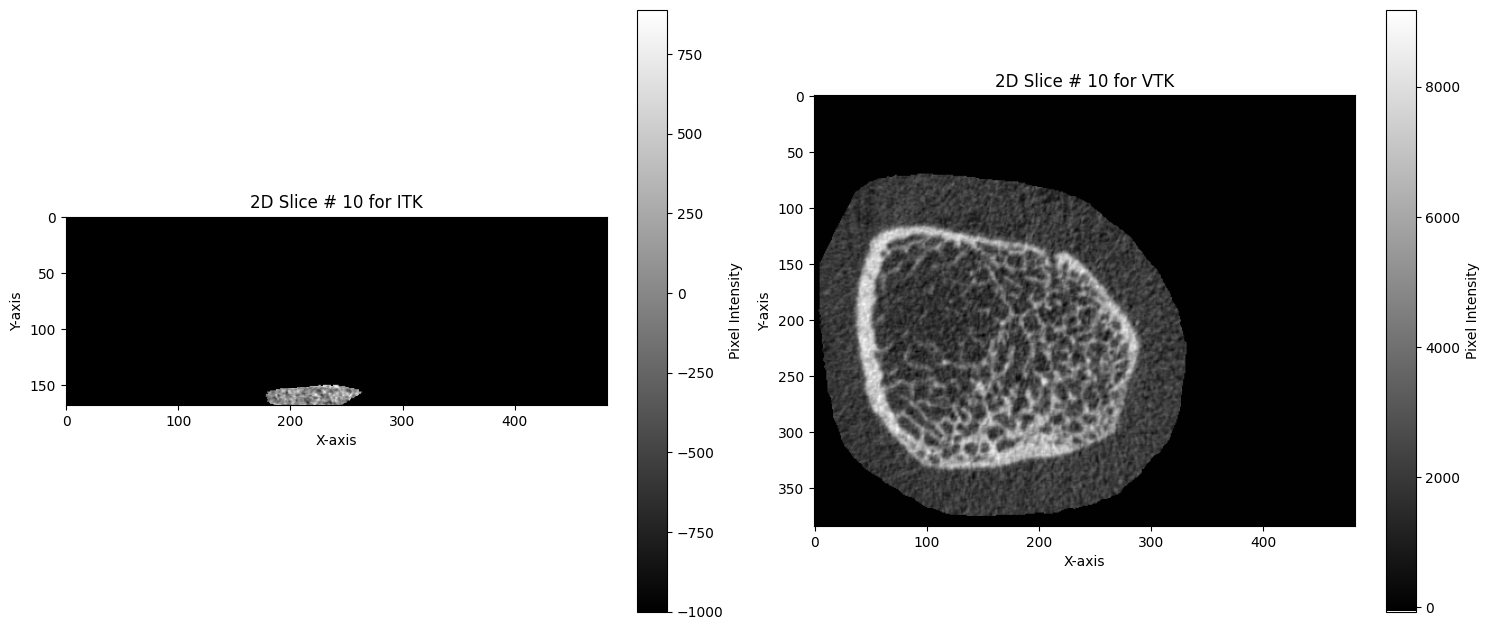

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15,15))

# ITK plot
im1 = axs[0].imshow(itk_selected_slice, cmap='gray', )
axs[0].set_title(f"2D Slice # {slice_index} for ITK")
axs[0].set_xlabel("X-axis")
axs[0].set_ylabel("Y-axis")
fig.colorbar(im1, ax=axs[0], fraction=0.05).set_label("Pixel Intensity")

# VTK plot
im2 = axs[1].imshow(vtk_selected_slice, cmap='gray')
axs[1].set_title(f"2D Slice # {slice_index} for VTK")
axs[1].set_xlabel("X-axis")
axs[1].set_ylabel("Y-axis")
fig.colorbar(im2, ax=axs[1], fraction=0.05).set_label("Pixel Intensity")

plt.tight_layout()
plt.show()

In [7]:
# ITK metadata
file_path = "images/DYNACT2_214_TMC_MID.AIM"
image = itk.imread(file_path)
metadata = dict(image)
metadata

{'CalibrationData': '68 kVp, BH: 200 mg HA/ccm, Scaling 8192, 0.2 CU',
 'CreationDate': '24-MAR-2023 09:43:26.20',
 'DataRange': (-860.0, 9852.0),
 'Energy': 68.0,
 'Intensity': 1.47,
 'MeasurementIndex': 17867,
 'ModificationDate': '28-MAR-2023 09:55:01.47',
 'MuScaling': 8192.0,
 'MuWater': 0.2396,
 'NumberOfProjections': 900,
 'NumberOfSamples': 2300,
 'PatientIndex': 3438,
 'PatientName': 'DYNACT2_214',
 'ReconstructionAlg': 3,
 'ReferenceLine': 121.763,
 'RescaleIntercept': -1000.0,
 'RescaleSlope': 0.5094754277963272,
 'RescaleType': 2,
 'RescaleUnits': 'mg HA/ccm',
 'SampleTime': 43.0,
 'ScanDistance': 139.61,
 'ScannerID': 3401,
 'ScannerType': 9,
 'Site': 4,
 'SliceIncrement': 0.06069643050432205,
 'SliceThickness': 0.06069643050432205,
 'Version': 'AIMDATA_V020   ',
 'origin': array([ 0.        , 15.35709953, 52.01990128]),
 'spacing': array([0.06069643, 0.0607    , 0.0607    ]),
 'direction': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])}

In [8]:
# VTK header data
_, _, aim_reader = aim_reader(aim_read_path)
processing_log = aim_reader.GetProcessingLog()
print(processing_log)   

!
! Processing Log
!
!-------------------------------------------------------------------------------
Created by                    ISQ_TO_AIM (IPL)                                  
Time                          28-MAR-2023 09:55:01.47                           
Original file                 DYNACT2_214_TMC_MID.ISQ                           
Original Creation-Date        24-MAR-2023 09:43:26.20                           
Orig-ISQ-Dim-p                                   2300       2300        168
Orig-ISQ-Dim-um                                139610     139610      10197
!-------------------------------------------------------------------------------
Patient Name                  DYNACT2_214                                       
Index Patient                                    3438
Index Measurement                               17867
!-------------------------------------------------------------------------------
Site                                                4
Scanner ID       

In [9]:
# VTK doesn't have the image positional automatically. A manual call is needed.
origin = reader.GetOrigin()
print("Origin: ", origin)

Origin:  (52.05024942755699, 15.387449830770493, 0.030348215252161026)


<a name="niftiWrite"></a>
## *Step 3: Compare NIFTI Write:*

Compare how vtkbone and ITK write the NIFTI file. A visual representation of a slice of the NIFTI image from each library will be shown. In addition the ITK metadata the NIFTI image will be shown. 

In [10]:
# Creating an ITK image from the AIM file
image = itk.imread(itk_nifti_write_path)

# Create the array for the image
img_array = np.asarray(image)

# Slice the image
itk_selected_slice = img_array[:, :, slice_index]

In [11]:
# Getting the vtkbone reader output AIM image
array, _ = nifti_reader(vtk_nifti_write_path)

# Slice the image
vtk_selected_slice = array[:, :, slice_index]

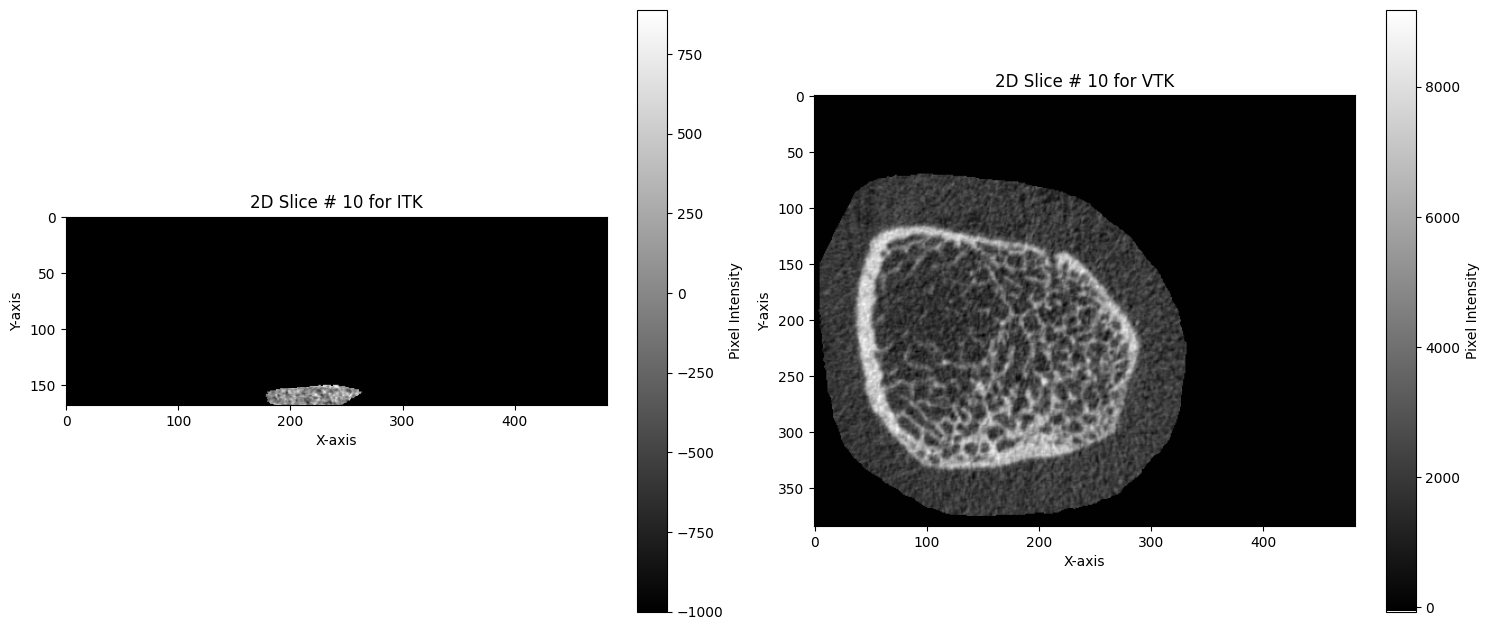

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(15,15))

# ITK plot
im1 = axs[0].imshow(itk_selected_slice, cmap='gray', )
axs[0].set_title(f"2D Slice # {slice_index} for ITK")
axs[0].set_xlabel("X-axis")
axs[0].set_ylabel("Y-axis")
fig.colorbar(im1, ax=axs[0], fraction=0.05).set_label("Pixel Intensity")

# VTK plot
im2 = axs[1].imshow(vtk_selected_slice, cmap='gray')
axs[1].set_title(f"2D Slice # {slice_index} for VTK")
axs[1].set_xlabel("X-axis")
axs[1].set_ylabel("Y-axis")
fig.colorbar(im2, ax=axs[1], fraction=0.05).set_label("Pixel Intensity")

plt.tight_layout()
plt.show()


In [13]:
# ITK metadata for the NIFTI file converter using ITK
file_path = "images/test/itk_test.nii"
image_itk = itk.imread(aim_read_path)
metadata_itk = dict(image_itk)
metadata_itk

{'CalibrationData': '68 kVp, BH: 200 mg HA/ccm, Scaling 8192, 0.2 CU',
 'CreationDate': '24-MAR-2023 09:43:26.20',
 'DataRange': (-860.0, 9852.0),
 'Energy': 68.0,
 'Intensity': 1.47,
 'MeasurementIndex': 17867,
 'ModificationDate': '28-MAR-2023 09:55:01.47',
 'MuScaling': 8192.0,
 'MuWater': 0.2396,
 'NumberOfProjections': 900,
 'NumberOfSamples': 2300,
 'PatientIndex': 3438,
 'PatientName': 'DYNACT2_214',
 'ReconstructionAlg': 3,
 'ReferenceLine': 121.763,
 'RescaleIntercept': -1000.0,
 'RescaleSlope': 0.5094754277963272,
 'RescaleType': 2,
 'RescaleUnits': 'mg HA/ccm',
 'SampleTime': 43.0,
 'ScanDistance': 139.61,
 'ScannerID': 3401,
 'ScannerType': 9,
 'Site': 4,
 'SliceIncrement': 0.06069643050432205,
 'SliceThickness': 0.06069643050432205,
 'Version': 'AIMDATA_V020   ',
 'origin': array([ 0.        , 15.35709953, 52.01990128]),
 'spacing': array([0.06069643, 0.0607    , 0.0607    ]),
 'direction': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])}

In [14]:
# ITK metadata for the NIFTI file converter using VTK

file_path = "images/test/vtk_test.nii"
image_vtk = itk.imread(file_path)
metadata_vtk = dict(image_vtk)
metadata_vtk

{'ITK_FileNotes': 'VTK8.2.0',
 'aux_file': '',
 'bitpix': '16',
 'cal_max': '0',
 'cal_min': '0',
 'datatype': '4',
 'descrip': 'VTK8.2.0',
 'dim[0]': '3',
 'dim[1]': '384',
 'dim[2]': '483',
 'dim[3]': '168',
 'dim[4]': '1',
 'dim[5]': '1',
 'dim[6]': '1',
 'dim[7]': '1',
 'dim_info': '0',
 'intent_code': '0',
 'intent_name': '',
 'intent_p1': '0',
 'intent_p2': '0',
 'intent_p3': '0',
 'nifti_type': '1',
 'pixdim[0]': '0',
 'pixdim[1]': '0.0607',
 'pixdim[2]': '0.0607',
 'pixdim[3]': '0.0606964',
 'pixdim[4]': '1',
 'pixdim[5]': '1',
 'pixdim[6]': '1',
 'pixdim[7]': '1',
 'qfac': 1.0,
 'qform_code': '1',
 'qform_code_name': 'NIFTI_XFORM_SCANNER_ANAT',
 'qoffset_x': '52.0503',
 'qoffset_y': '15.3875',
 'qoffset_z': '0.0303482',
 'qto_xyz': itkMatrixF44 ([[0.06069999933242798, 0.0, 0.0, 52.05025100708008], [0.0, 0.06069999933242798, 0.0, 15.387450218200684], [0.0, 0.0, 0.06069643050432205, 0.030348215252161026], [0.0, 0.0, 0.0, 1.0]]),
 'quatern_b': '0',
 'quatern_c': '0',
 'quatern_d'

---
<a name="attribution"></a>

Notebook created using the [template](https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb) of the [ORMIR community](https://ormircommunity.github.io/) (version 1.0, 2023)